# RQ1 & RQ3 — Cloud-native vs. Traditional Geospatial QueriesAnalysis of single-machine query benchmarks comparing Local (Python),PostGIS and DuckDB across three workload types and two dataset sizes.

In [1]:
from __future__ import annotations

import platform
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import yaml

from src.analysis.loading import (
    enrich_samples, load_costs, load_experiments, load_metadata, load_samples,
)
from src.analysis.tables import (
    build_consistency_table, build_cross_pass_table,
    build_descriptive_table, build_pairwise_table,
    build_rq1_ranking, build_scaling_table,
    compact_descriptive_table, format_consistency_table,
    format_ranking_table, split_pairwise_effects,
    split_pairwise_significance,
)
from src.analysis.validation import run_all_validations
from src.plotting.style import StyleConfig
from src.plotting.charts import (
    plot_median_bars, plot_violin,
    plot_cpu_breakdown, plot_network_io, plot_cv_iqr,
    plot_cross_workload, plot_size_scaling, plot_ranking_stability,
)

In [2]:
RUN_ID = "2026-05-23-0NVQKS"
BLOB_STORAGE_ACCOUNT_NAME = "doppabs"
BENCHMARK_CONTAINER = "benchmarks"
METADATA_CONTAINER = "metadata"
BENCHMARK_METADATA_BLOB_NAME = "benchmark_metadata.parquet"
BENCHMARKS_YML_PATH = Path("../doppa/benchmarks.yml")

FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

PRIMARY_METRICS = ["elapsed_time", "network_bytes_received", "network_bytes_sent"]
AUXILIARY_METRICS = ["cpu_time_user_seconds", "cpu_time_system_seconds"]

ITERATION_CEILINGS = {
    "point-in-polygon-lookup": 2500,
    "knn-search": 4000,
    "bbox-filtering": 900,
    "national-scale-spatial-join": 5,
}
WORKLOAD_TYPES = sorted(ITERATION_CEILINGS.keys(), key=len, reverse=True)

RQ1_WORKLOADS = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]
RQ1_CONFIGS = ["local", "postgis", "duckdb"]

style = StyleConfig()
style.apply_rcparams()

## Data Loading

In [3]:
db = duckdb.connect()
db.install_extension("azure")
db.load_extension("azure")
db.execute(f"""
    CREATE OR REPLACE SECRET azure_secret(
        TYPE azure, PROVIDER config, ACCOUNT_NAME '{BLOB_STORAGE_ACCOUNT_NAME}'
    );
""")
if platform.system() == "Linux":
    db.execute("SET azure_transport_option_type = curl")

experiments = load_experiments(BENCHMARKS_YML_PATH)
samples_df = load_samples(db, BENCHMARK_CONTAINER, RUN_ID)
metadata_df = load_metadata(db, METADATA_CONTAINER, BENCHMARK_METADATA_BLOB_NAME, RUN_ID)
costs_df = load_costs(db, BENCHMARK_CONTAINER, RUN_ID)
samples_df = enrich_samples(samples_df, experiments, WORKLOAD_TYPES, ITERATION_CEILINGS)
successful_all = samples_df[samples_df["status"] == "success"].copy()

print(f"Loaded {len(samples_df)} samples, {len(successful_all)} successful")
print(f"Workloads: {sorted(samples_df['workload_type'].unique())}")
print(f"Dataset sizes: {sorted(samples_df['dataset_size'].unique())}")

Loaded 6065 samples, 6063 successful
Workloads: ['bbox-filtering', 'knn-search', 'national-scale-spatial-join', 'point-in-polygon-lookup']
Dataset sizes: ['large', 'small']


## Validation

In [4]:
run_all_validations(samples_df, successful_all, metadata_df, experiments)

Schema V4 check passed
query_id                                                           benchmark_run
national-scale-spatial-join-databricks-partitioned-16-nodes-large  1                1.0
national-scale-spatial-join-databricks-partitioned-2-nodes-large   1                1.0
dtype: float64
                                             query_id  achieved_iterations  \
6   national-scale-spatial-join-databricks-broadca...                  5.0   
8   national-scale-spatial-join-databricks-default...                  5.0   
9   national-scale-spatial-join-databricks-default...                  0.0   
10  national-scale-spatial-join-databricks-default...                  0.0   
11  national-scale-spatial-join-databricks-partiti...                  0.0   
12  national-scale-spatial-join-databricks-partiti...                  0.0   

    sample_n  
6        NaN  
8        NaN  
9        NaN  
10       NaN  
11       NaN  
12       NaN  
Batch run_id consistency check complete
Result cardin

In [5]:
successful = successful_all[successful_all["workload_type"].isin(RQ1_WORKLOADS)].copy()
samples_rq1 = samples_df[samples_df["workload_type"].isin(RQ1_WORKLOADS)].copy()

print(f"RQ1 data: {len(successful)} successful iterations")
print(f"Configurations: {sorted(successful['configuration'].unique())}")
print(f"Dataset sizes: {sorted(successful['dataset_size'].unique())}")

RQ1 data: 6058 successful iterations
Configurations: ['duckdb', 'local', 'postgis']
Dataset sizes: ['small']


## Statistical Analysis

In [6]:
all_metrics = PRIMARY_METRICS + AUXILIARY_METRICS

table1 = build_descriptive_table(successful, all_metrics)
print(f"Table 1 (descriptive): {len(table1)} rows")
table1.head(10)

Table 1 (descriptive): 45 rows


n  \
query_id                    benchmark_run metric                         
bbox-filtering-duckdb-small 1             cpu_time_system_seconds   33   
                                          cpu_time_user_seconds     33   
                                          elapsed_time              33   
                                          network_bytes_received    33   
                                          network_bytes_sent        33   
bbox-filtering-local-small  1             cpu_time_system_seconds  771   
                                          cpu_time_user_seconds    771   
                                          elapsed_time             771   
                                          network_bytes_received   771   
                                          network_bytes_sent       771   

                                                                         median  \
query_id                    benchmark_run metric                                  
bbox-filtering-duckdb-small 1             cpu_time_system_seconds      0.060000   
                                          cpu_time_user_seconds        4.560000   
                                          elapsed_time                 1.829268   
                                          network_bytes_received   93323.000000   
                                          network_bytes_sent         906.000000   
bbox-filtering-local-small  1             cpu_time_system_seconds      0.010000   
                                          cpu_time_user_seconds        0.050000   
                                          elapsed_time                 0.055777   
                                          network_bytes_received       0.000000   
                                          network_bytes_sent          66.000000   

                                                                           mean  \
query_id                    benchmark_run metric                                  
bbox-filtering-duckdb-small 1             cpu_time_system_seconds      0.061818   
                                          cpu_time_user_seconds        4.825455   
                                          elapsed_time                 1.826346   
                                          network_bytes_received   93301.000000   
                                          network_bytes_sent         928.242424   
bbox-filtering-local-small  1             cpu_time_system_seconds      0.005396   
                                          cpu_time_user_seconds        0.053696   
                                          elapsed_time                 0.058911   
                                          network_bytes_received       0.000000   
                                          network_bytes_sent          66.005188   

                                                                         std  \
query_id                    benchmark_run metric                               
bbox-filtering-duckdb-small 1             cpu_time_system_seconds   0.030047   
                                          cpu_time_user_seconds     0.712277   
                                          elapsed_time              0.274617   
                                          network_bytes_received   31.595095   
                                          network_bytes_sent       45.576193   
bbox-filtering-local-small  1             cpu_time_system_seconds   0.005014   
                                          cpu_time_user_seconds     0.016418   
                                          elapsed_time              0.016067   
                                          network_bytes_received    0.000000   
                                          network_bytes_sent        3.467096   

                                                                         cv  \
query_id                    benchmark_run metric                              
bbox-filtering-duckdb-small 1             cpu_time_system_seconds  

In [7]:
table2 = build_cross_pass_table(table1)
print(f"Table 2 (cross-pass): {len(table2)} rows")
if len(table2) > 0:
    inconsistent = table2[~table2["consistent"]]
    print(f"  {len(inconsistent)} inconsistent (EXPLORATORY)")
table2.head(10)

Table 2 (cross-pass): 0 rows


,,headline_median,pass_1_median,pass_2_median,pass_3_median,pass_range,pass_range_relative,consistent
query_id,metric,,,,,,,


In [8]:
table3 = build_pairwise_table(successful, PRIMARY_METRICS)
print(f"Table 3 (pairwise): {len(table3)} rows")
table3.head(10)

Table 3 (pairwise): 27 rows


n_paired  \
workload_type  dataset_size config_a config_b benchmark_run metric                             
bbox-filtering small        duckdb   local    1             elapsed_time                  33   
                                                            network_bytes_received        33   
                                                            network_bytes_sent            33   
                                     postgis  1             elapsed_time                  33   
                                                            network_bytes_received        33   
                                                            network_bytes_sent            33   
                            local    postgis  1             elapsed_time                  33   
                                                            network_bytes_received        33   
                                                            network_bytes_sent            33   
knn-search     small        duckdb   local    1             elapsed_time                  46   

                                                                                    wilcoxon_stat  \
workload_type  dataset_size config_a config_b benchmark_run metric                                  
bbox-filtering small        duckdb   local    1             elapsed_time                      0.0   
                                                            network_bytes_received            0.0   
                                                            network_bytes_sent                0.0   
                                     postgis  1             elapsed_time                      0.0   
                                                            network_bytes_received            0.0   
                                                            network_bytes_sent                0.0   
                            local    postgis  1             elapsed_time                     33.0   
                                                            network_bytes_received            0.0   
                                                            network_bytes_sent                0.0   
knn-search     small        duckdb   local    1             elapsed_time                      0.0   

                                                                                         p_value  \
workload_type  dataset_size config_a config_b benchmark_run metric                                 
bbox-filtering small        duckdb   local    1             elapsed_time            2.328306e-10   
                                                            network_bytes_received  1.753364e-07   
                                                            network_bytes_sent      2.473126e-07   
                                     postgis  1             elapsed_time            2.328306e-10   
                                                            network_bytes_received  5.344128e-07   
                                                            network_bytes_sent      5.360840e-07   
                            local    postgis  1             elapsed_time            7.480849e-07   
                                                            network_bytes_received  5.330235e-07   
                                                            network_bytes_sent      5.346910e-07   
knn-search     small        duckdb   local    1             elapsed_time            2.842171e-14   

                                                                                         a12  \
workload_type  dataset_size config_a config_b benchmark_run metric                             
bbox-filtering small        duckdb   local    1             elapsed_time            1.000000   
                                                            network_bytes_received  1.000000   
                                                            network_bytes_sent      1.000000   
                                     

In [9]:
table4 = build_consistency_table(table3)
if len(table4) > 0:
    fc = table4["fully_consistent"].sum()
    total = len(table4)
    print(f"Table 4 (consistency): {total} comparisons, {fc} fully consistent ({fc / total:.0%})")
table4.head(10)

Table 4 (consistency): 27 comparisons, 25 fully consistent (93%)


direction_consistent  \
workload_type  dataset_size config_a config_b metric                                         
bbox-filtering small        duckdb   local    elapsed_time                            True   
                                              network_bytes_received                 False   
                                              network_bytes_sent                      True   
                                     postgis  elapsed_time                            True   
                                              network_bytes_received                  True   
                                              network_bytes_sent                      True   
                            local    postgis  elapsed_time                            True   
                                              network_bytes_received                  True   
                                              network_bytes_sent                      True   
knn-search     small        duckdb   local    elapsed_time                            True   

                                                                      all_significant  \
workload_type  dataset_size config_a config_b metric                                    
bbox-filtering small        duckdb   local    elapsed_time                       True   
                                              network_bytes_received             True   
                                              network_bytes_sent                 True   
                                     postgis  elapsed_time                       True   
                                              network_bytes_received             True   
                                              network_bytes_sent                 True   
                            local    postgis  elapsed_time                       True   
                                              network_bytes_received             True   
                                              network_bytes_sent                 True   
knn-search     small        duckdb   local    elapsed_time                       True   

                                                                      effect_size_consistent  \
workload_type  dataset_size config_a config_b metric                                           
bbox-filtering small        duckdb   local    elapsed_time                              True   
                                              network_bytes_received                    True   
                                              network_bytes_sent                        True   
                                     postgis  elapsed_time                              True   
                                              network_bytes_received                    True   
                                              network_bytes_sent                        True   
                            local    postgis  elapsed_time                              True   
                                              network_bytes_received                    True   
                                              network_bytes_sent                        True   
knn-search     small        duckdb   local    elapsed_time                              True   

                                                                      fully_consistent  
workload_type  dataset_size config_a config_b metric                                    
bbox-filtering small        duckdb   local    elapsed_time                        True  
                                              network_bytes_received             False  
                                              network_bytes_sent                  True  
                                     postgis  elapsed_time                        True  
                                              network_bytes_received              True  
                                              network_bytes_sent                  True  
       

## RQ1 — Cloud-native vs. Traditional

In [10]:
rq1_comparisons = table3.reset_index()
rq1_comparisons = rq1_comparisons[rq1_comparisons["workload_type"].isin(RQ1_WORKLOADS)]

rq1_consistency = table4.reset_index()
rq1_consistency = rq1_consistency[rq1_consistency["workload_type"].isin(RQ1_WORKLOADS)]

rq1_ranking = build_rq1_ranking(rq1_comparisons, rq1_consistency, table1, table2)
print("RQ1 Ranking Table:")
rq1_ranking

RQ1 Ranking Table:


fastest  \
workload_type           dataset_size metric                            
bbox-filtering          small        elapsed_time            postgis   
                                     network_bytes_received    local   
                                     network_bytes_sent        local   
knn-search              small        elapsed_time            postgis   
                                     network_bytes_received    local   
                                     network_bytes_sent        local   
point-in-polygon-lookup small        elapsed_time            postgis   
                                     network_bytes_received    local   
                                     network_bytes_sent        local   

                                                             consistent  \
workload_type           dataset_size metric                               
bbox-filtering          small        elapsed_time                  True   
                                     network_bytes_received       False   
                                     network_bytes_sent            True   
knn-search              small        elapsed_time                  True   
                                     network_bytes_received        True   
                                     network_bytes_sent            True   
point-in-polygon-lookup small        elapsed_time                  True   
                                     network_bytes_received       False   
                                     network_bytes_sent            True   

                                                             median_postgis  \
workload_type           dataset_size metric                                   
bbox-filtering          small        elapsed_time              3.840290e-02   
                                     network_bytes_received    1.702847e+06   
                                     network_bytes_sent        1.193200e+04   
knn-search              small        elapsed_time              4.196677e-03   
                                     network_bytes_received    8.688000e+03   
                                     network_bytes_sent        6.280000e+02   
point-in-polygon-lookup small        elapsed_time              1.423183e-02   
                                     network_bytes_received    1.877000e+03   
                                     network_bytes_sent        3.048000e+03   

                                                             median_duckdb  \
workload_type           dataset_size metric                                  
bbox-filtering          small        elapsed_time                 1.829268   
                                     network_bytes_received   93323.000000   
                                     network_bytes_sent         906.000000   
knn-search              small        elapsed_time                 0.913020   
                                     network_bytes_received   93257.000000   
                                     network_bytes_sent         840.000000   
point-in-polygon-lookup small        elapsed_time                17.513835   
                                     network_bytes_received  933230.000000   
                                     network_bytes_sent        8633.000000   

                                                             median_local  
workload_type           dataset_size metric                                
bbox-filtering          small        elapsed_time                0.055777  
                                     network_bytes_received      0.000000  
                                     network_bytes_sent         66.000000  
knn-search              small        elapsed_time               77.769208  
                                     network_bytes_received     42.000000  
                                     network_bytes_sent        108.000000  
point-in-polygon-lookup small        elapsed_time                3.583268  
                             

## RQ3 — Consistency Across Patterns

In [11]:
rq3_data = rq1_consistency[rq1_consistency["metric"] == "elapsed_time"].copy()

if len(rq3_data) > 0:
    rq3_pivot = rq3_data.pivot_table(
        index=["config_a", "config_b"],
        columns="workload_type",
        values="direction_consistent",
        aggfunc="all",
    )
    print("RQ3 Cross-workload agreement (elapsed_time, direction consistency):")
    display(rq3_pivot)
else:
    print("No RQ1 consistency data available for RQ3 analysis")

RQ3 Cross-workload agreement (elapsed_time, direction consistency):


workload_type      bbox-filtering  knn-search  point-in-polygon-lookup
config_a config_b                                                     
duckdb   local               True        True                     True
         postgis             True        True                     True
local    postgis             True        True                     True

## Visualisation

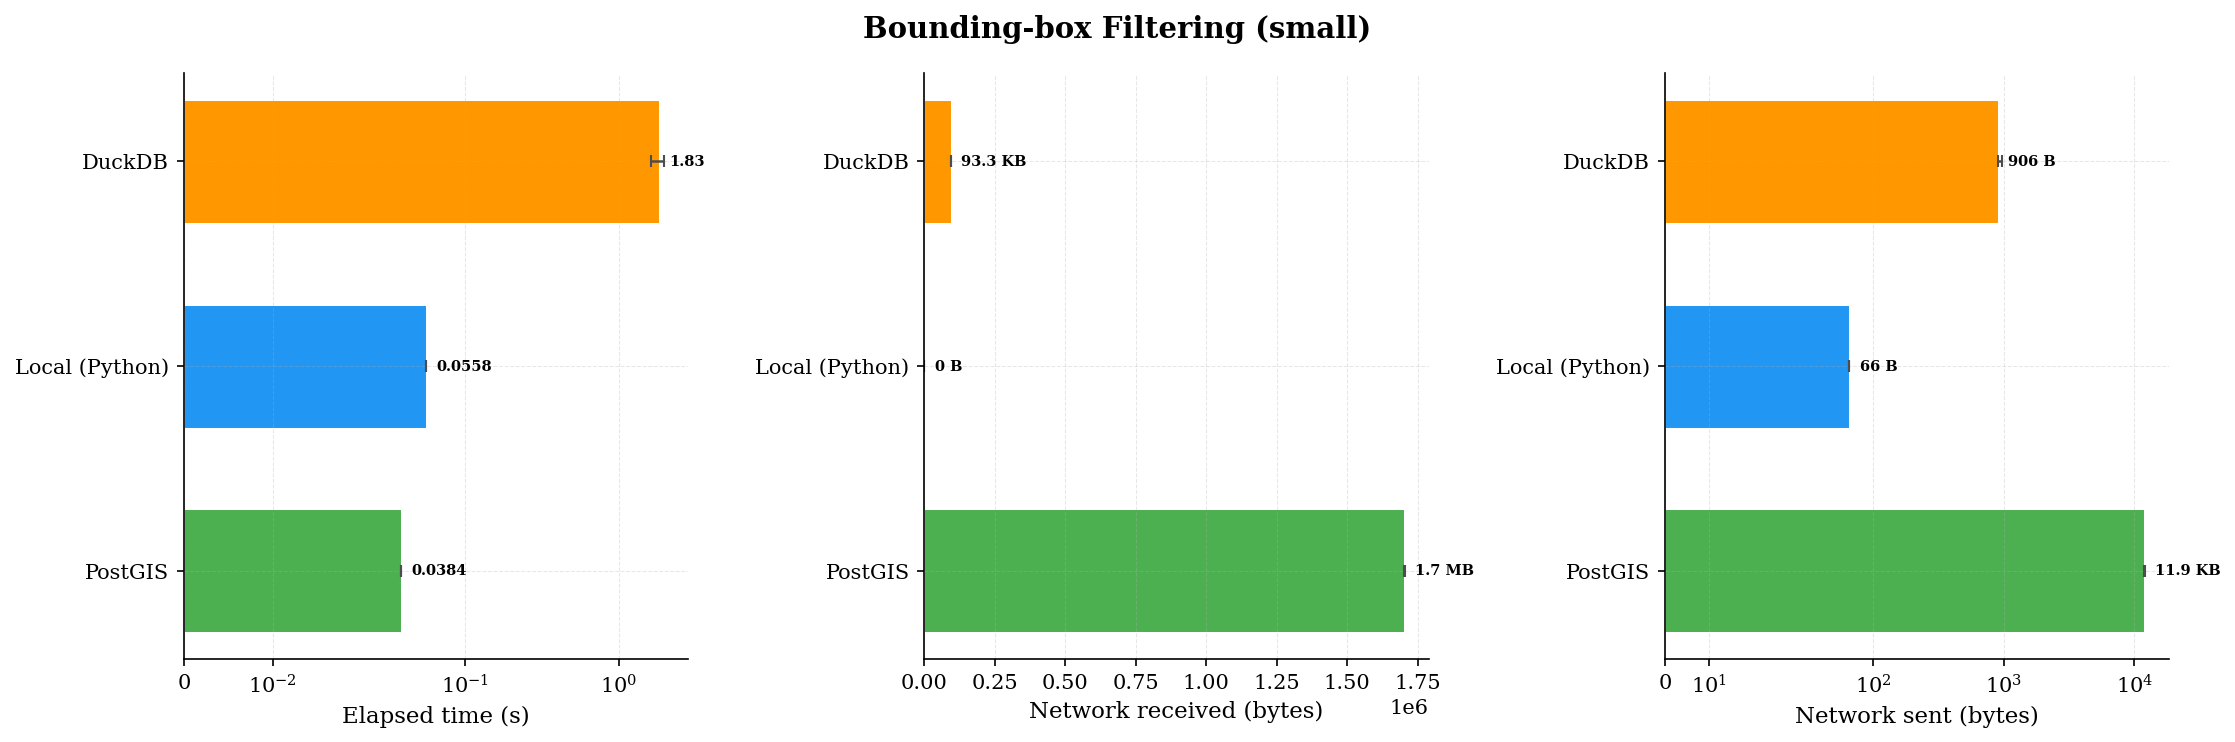

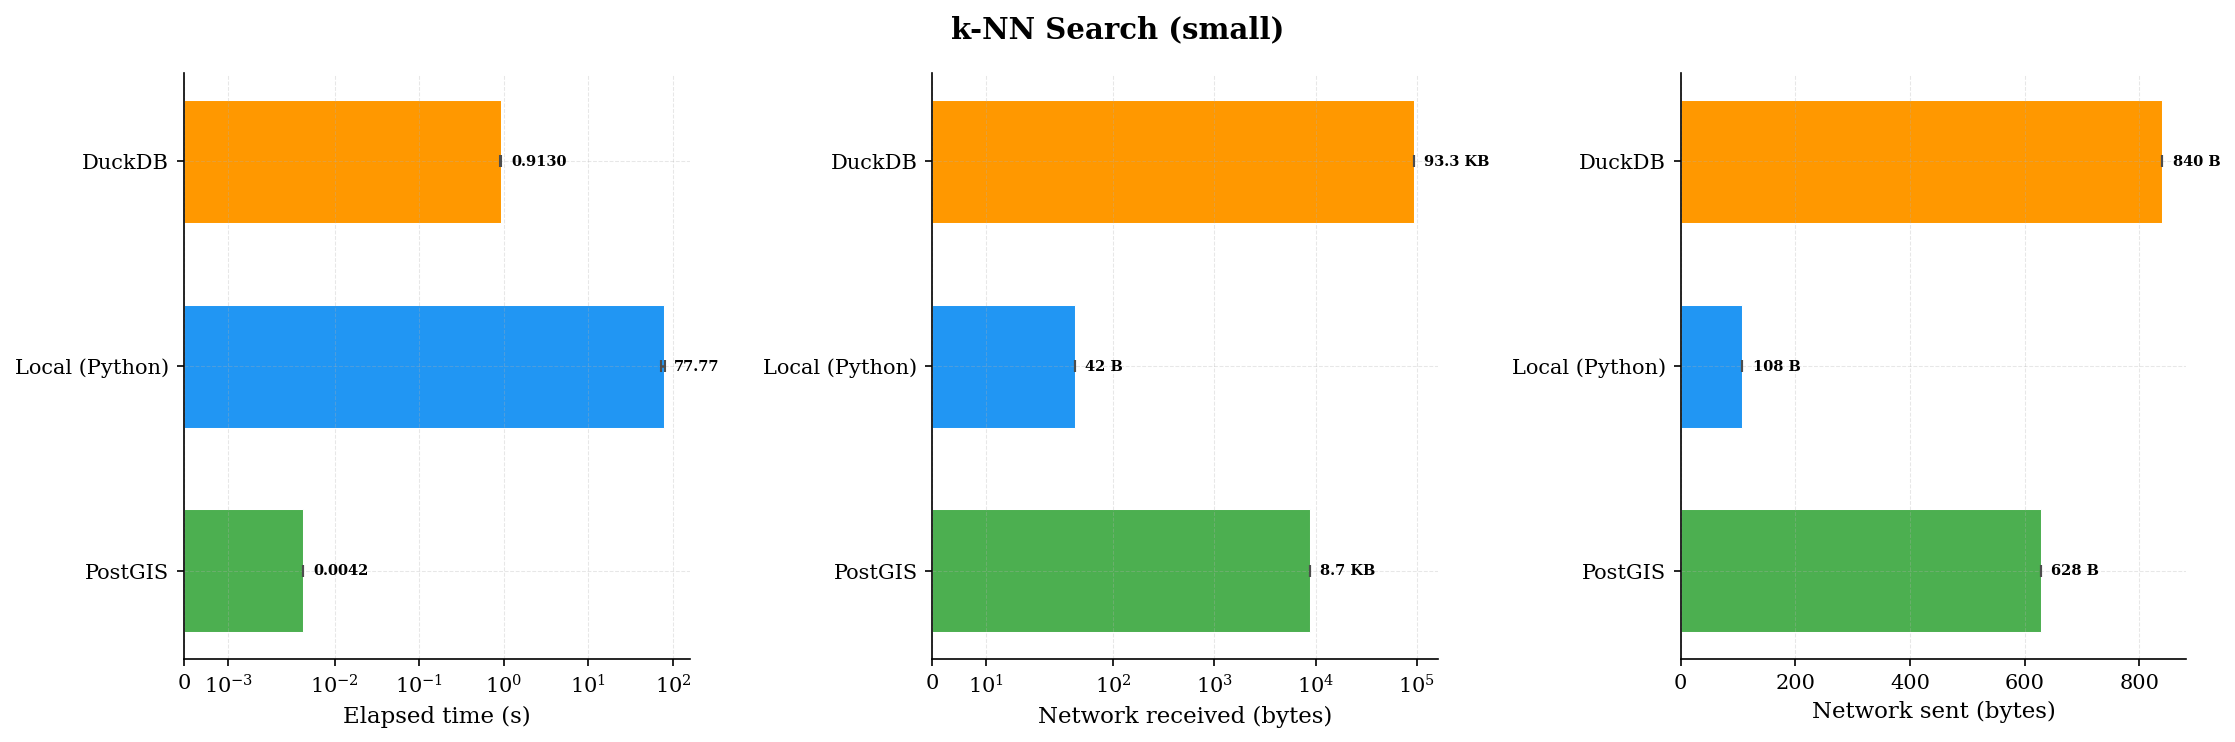

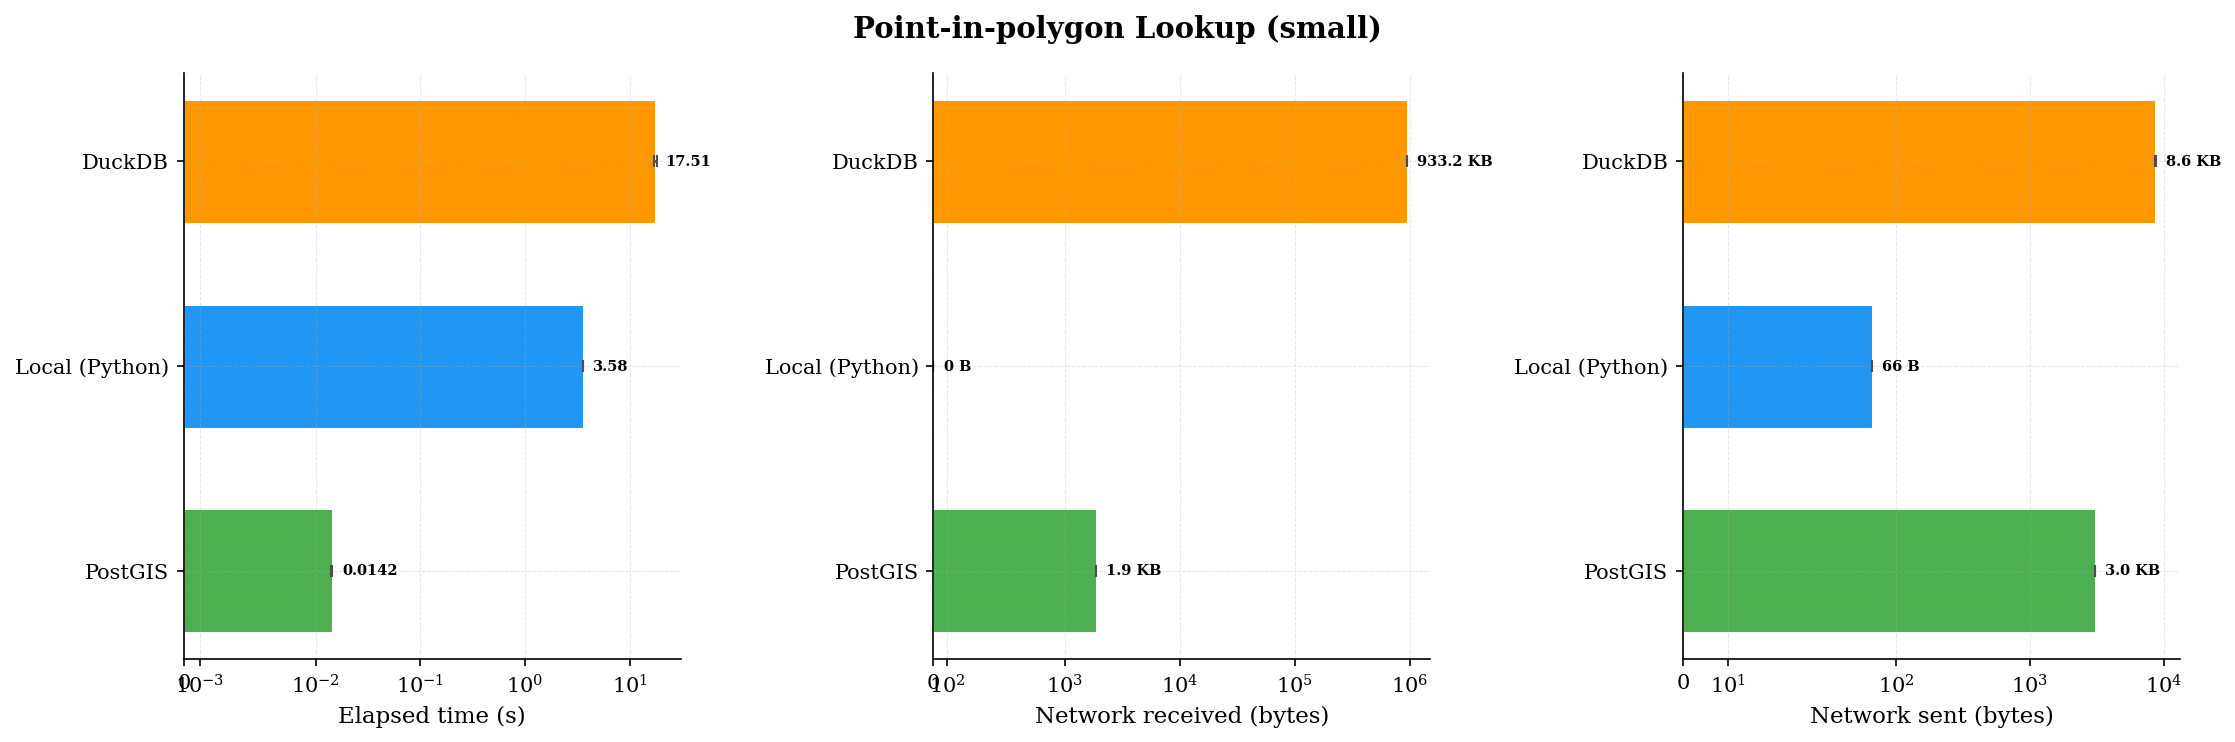

In [12]:
plot_median_bars(successful, PRIMARY_METRICS, style, FIGURES_DIR)

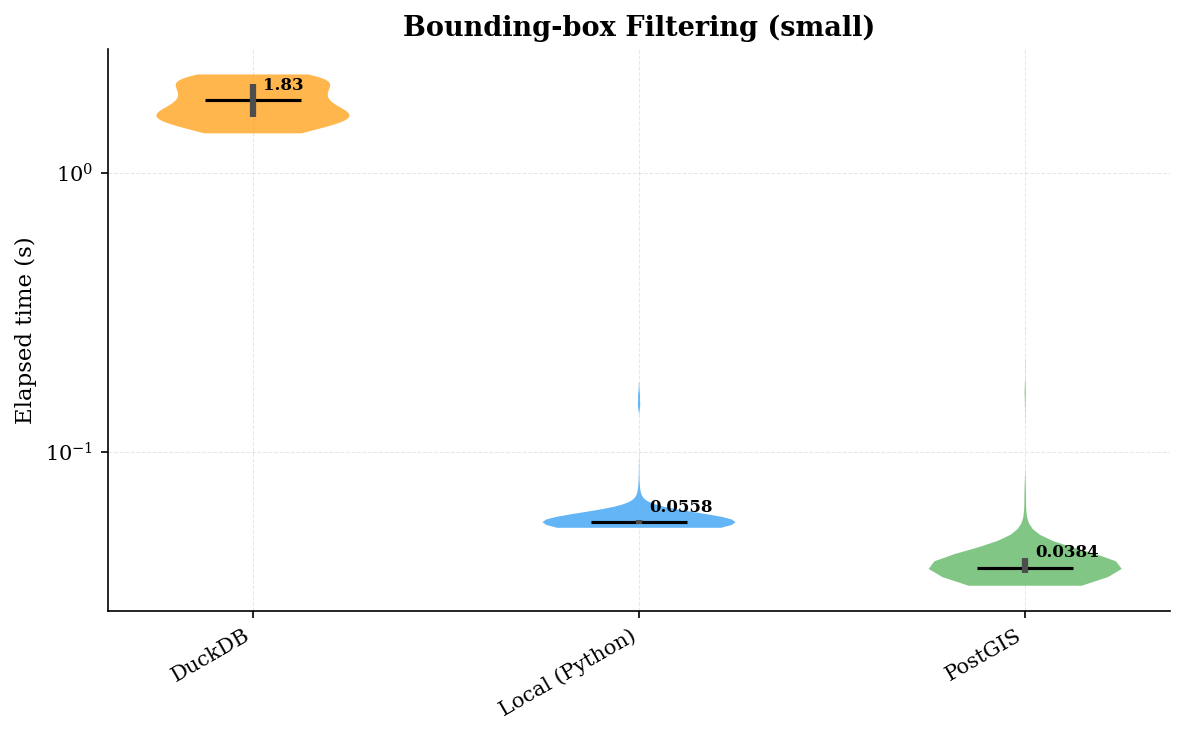

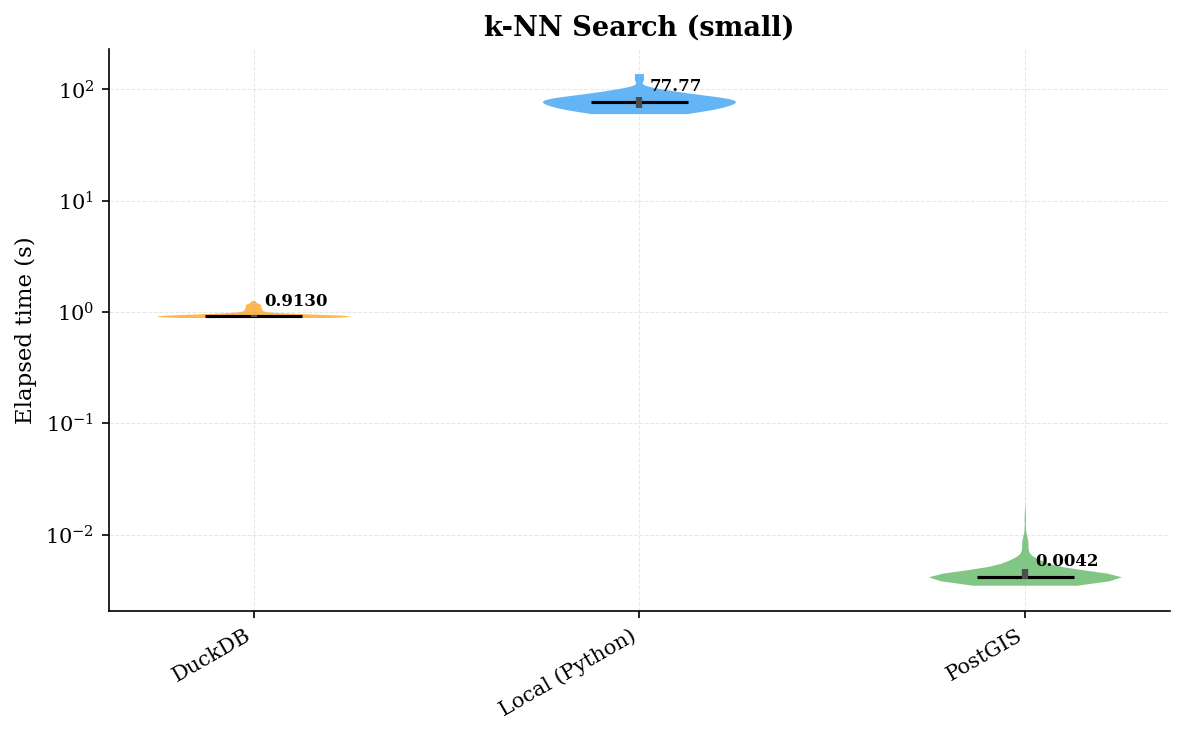

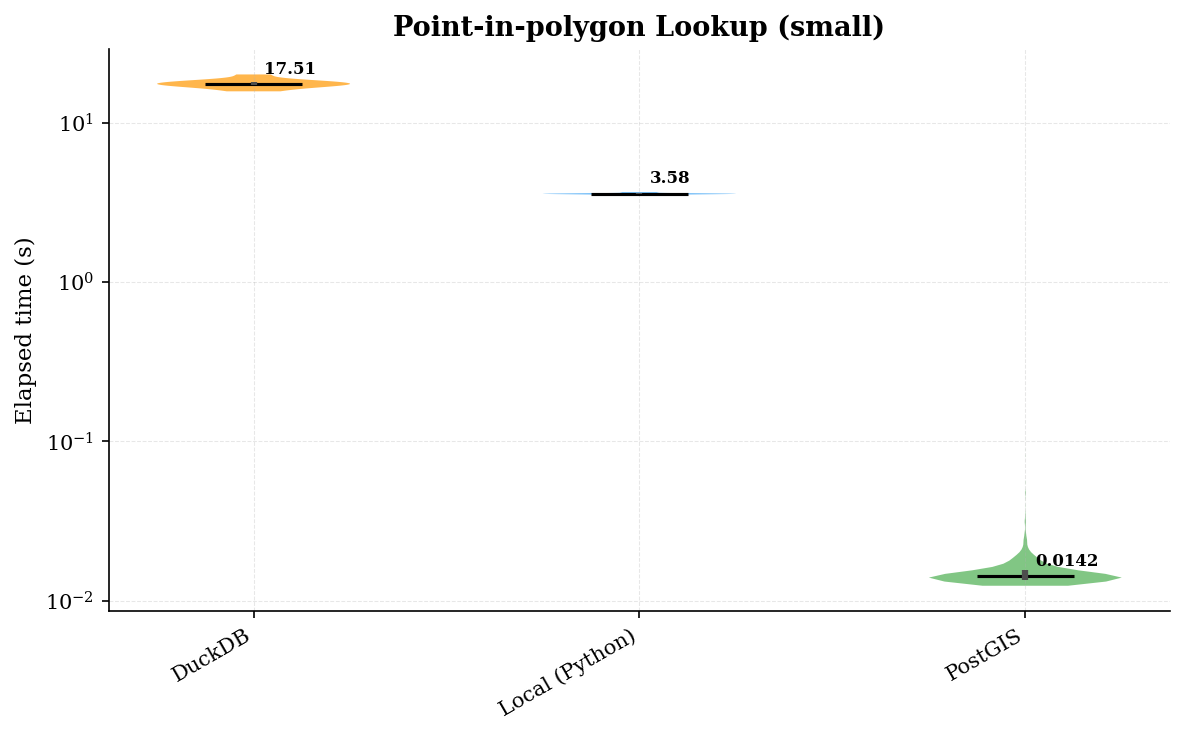

In [13]:
plot_violin(successful, style, FIGURES_DIR)

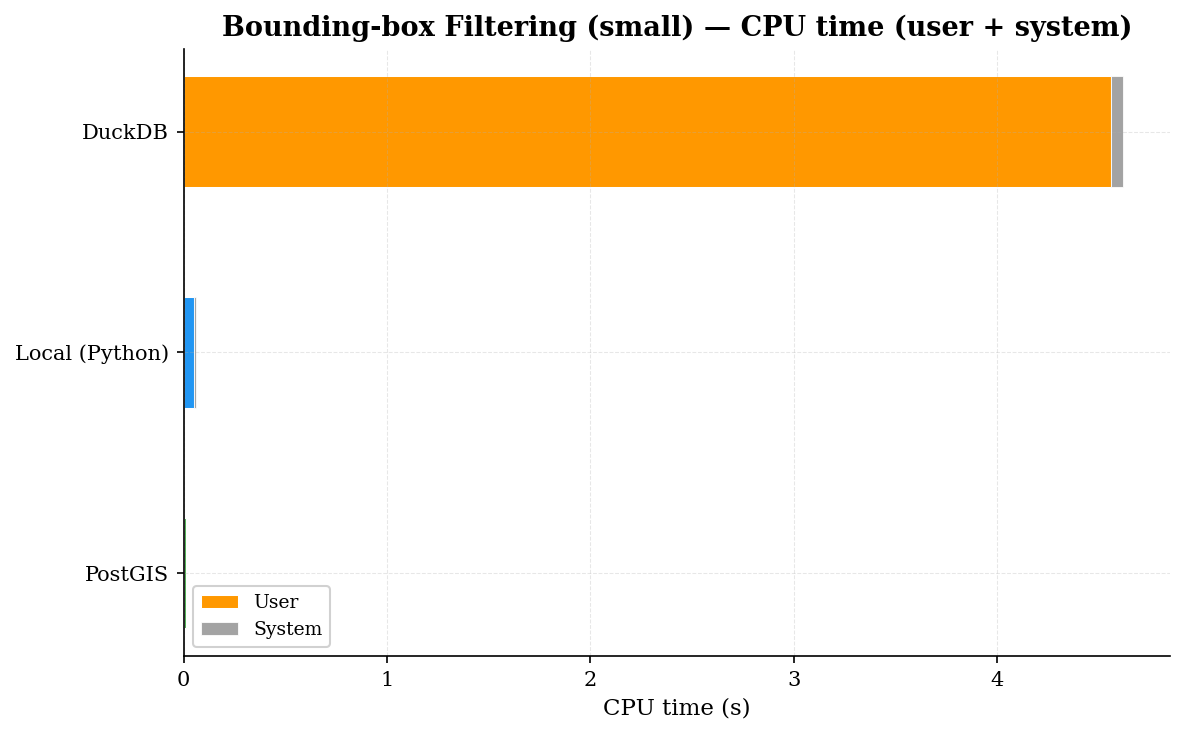

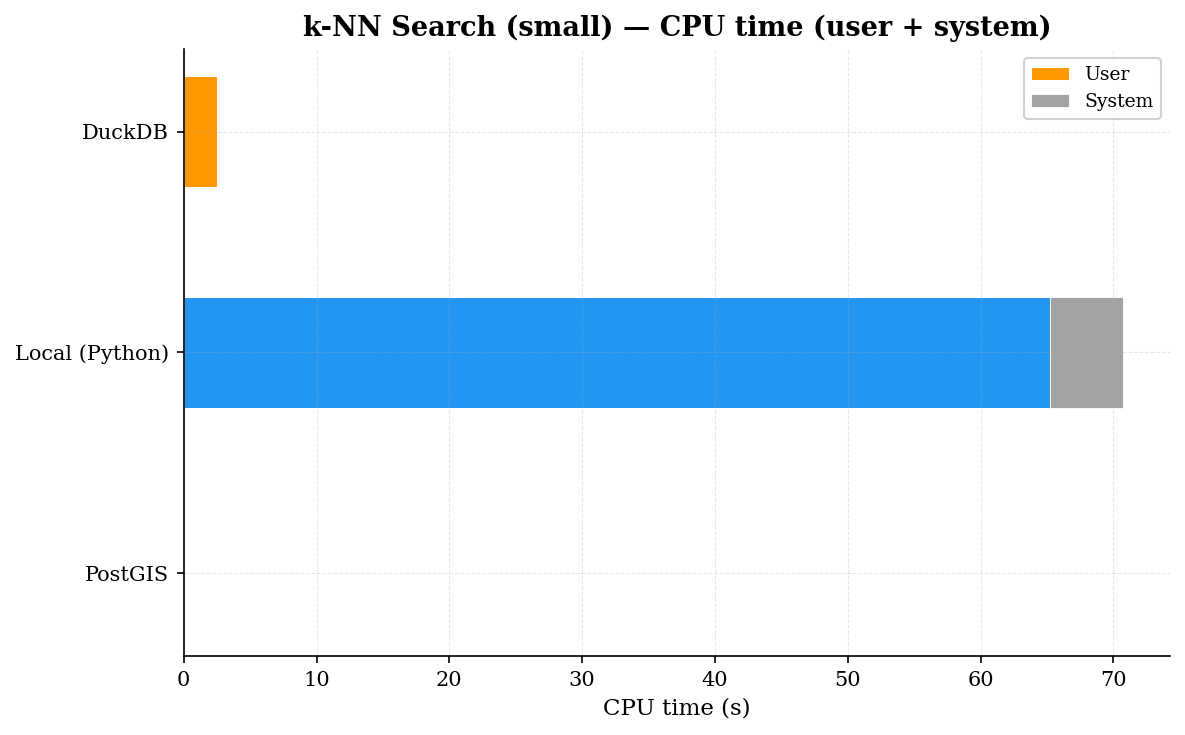

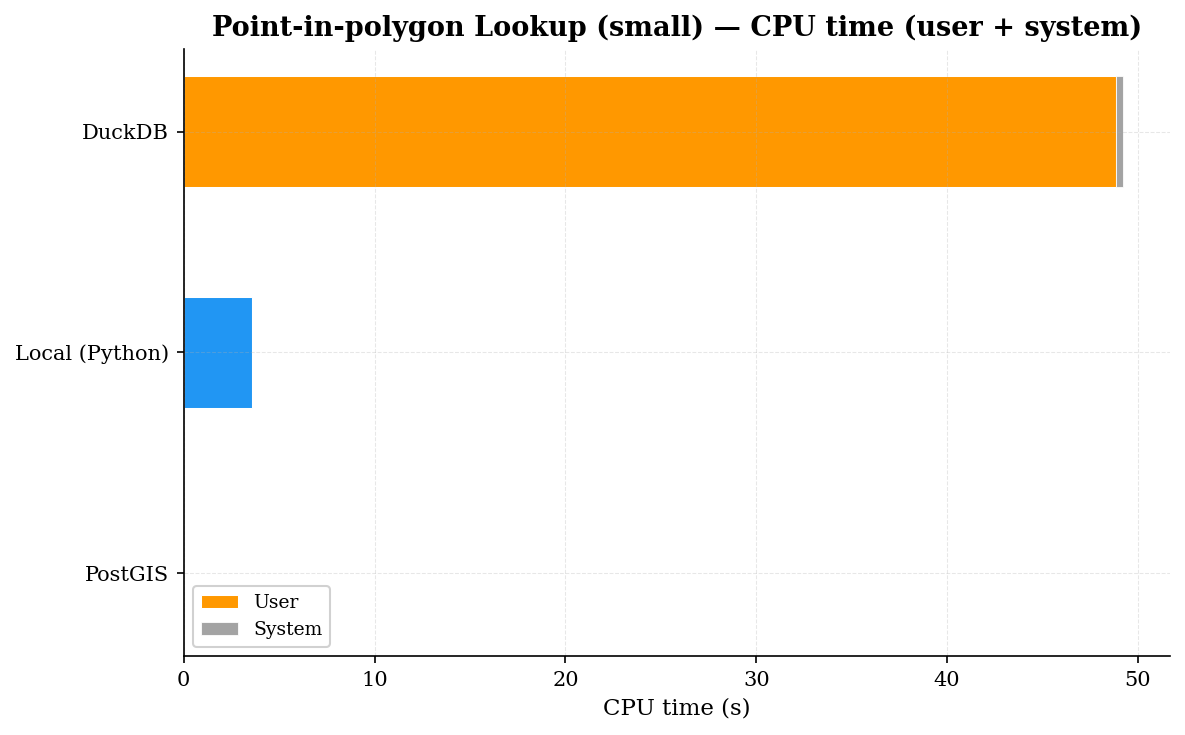

In [14]:
plot_cpu_breakdown(successful, style, FIGURES_DIR)

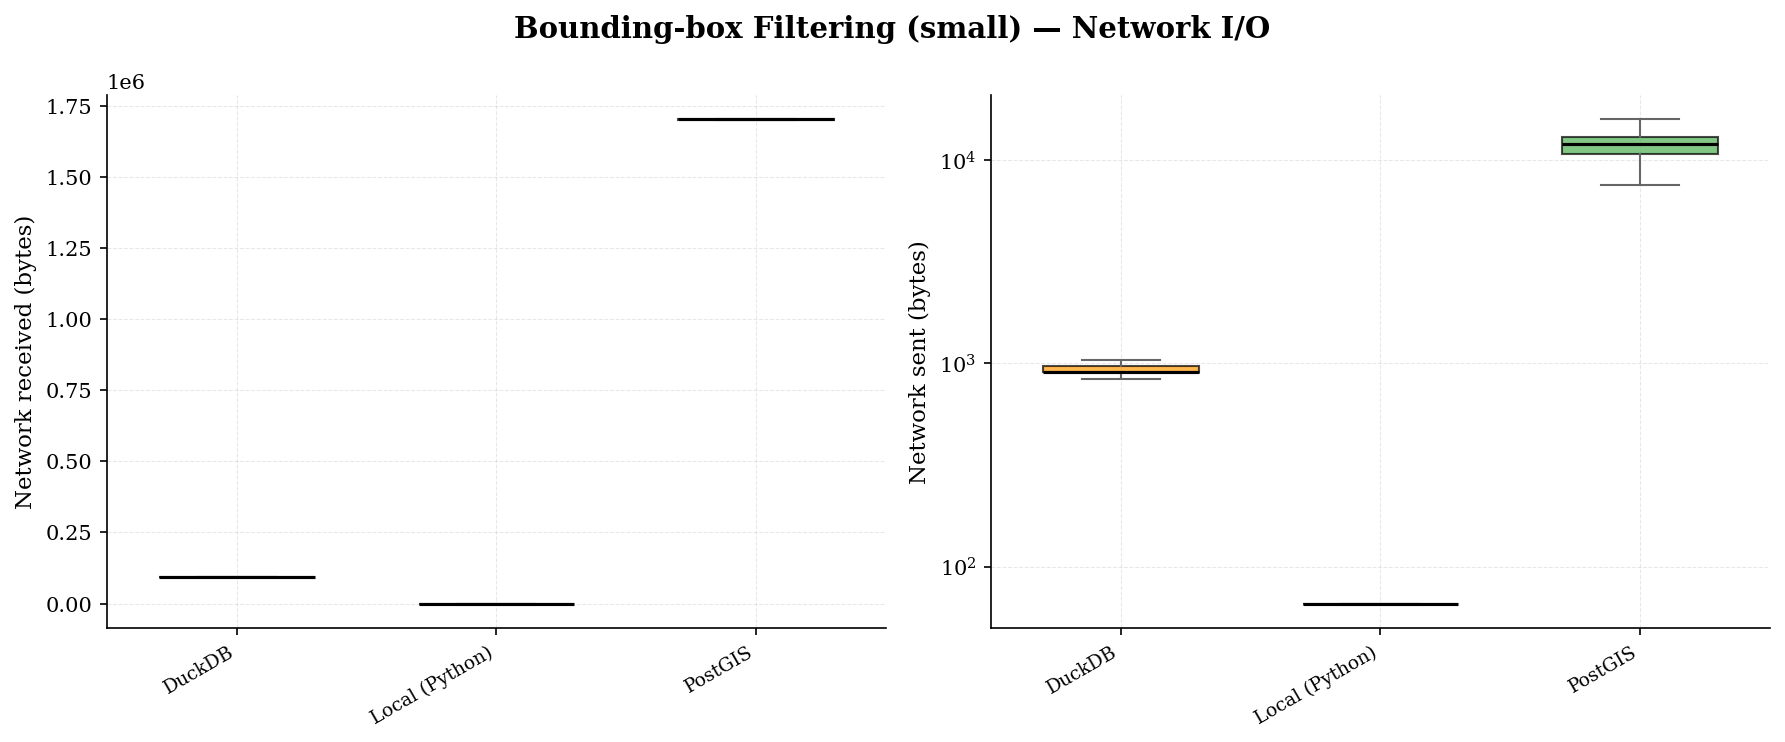

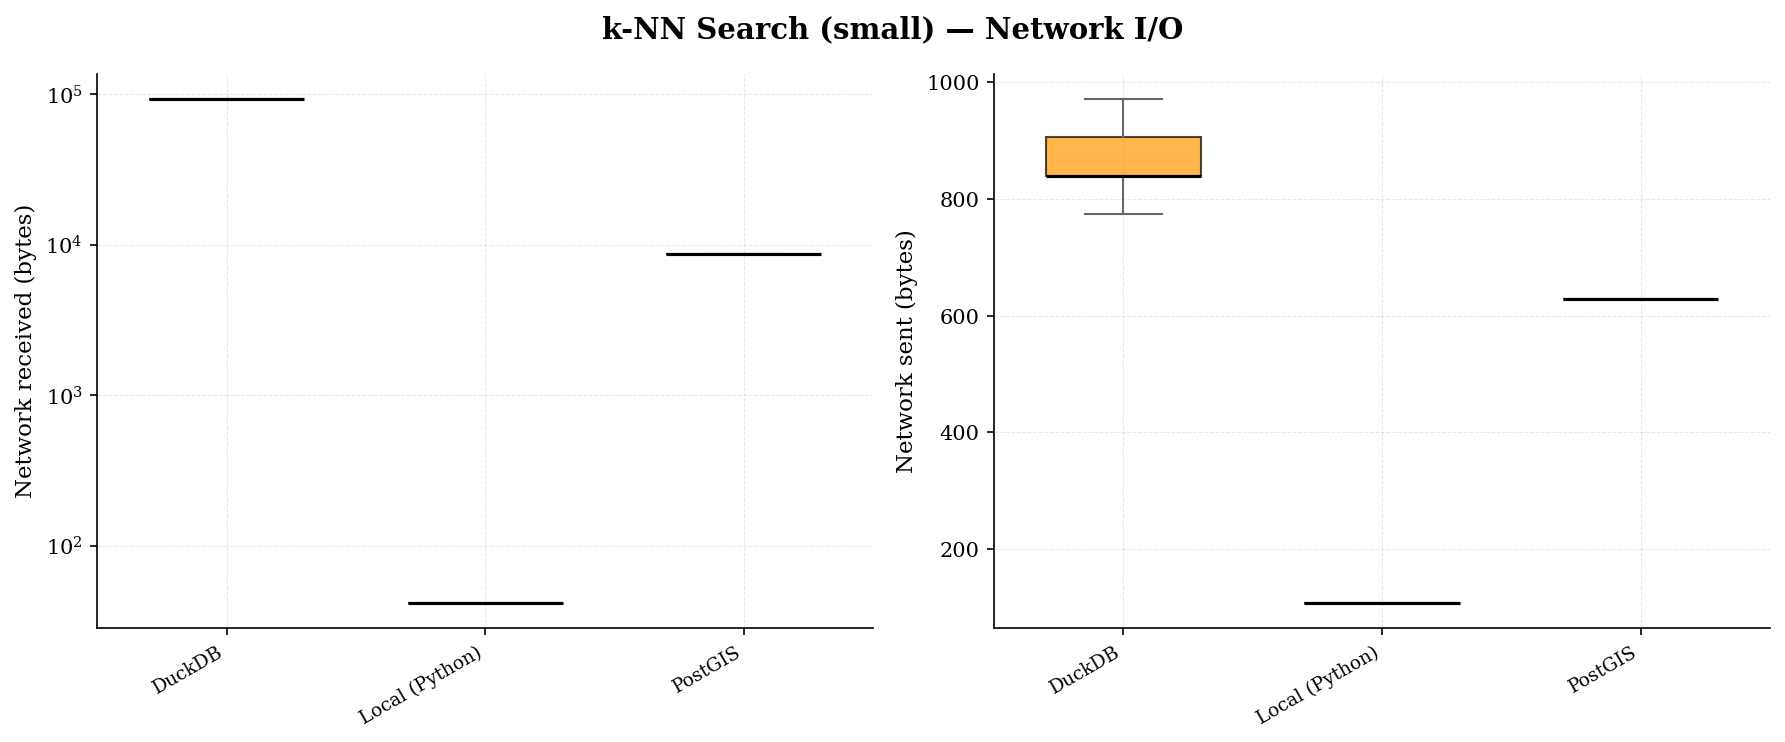

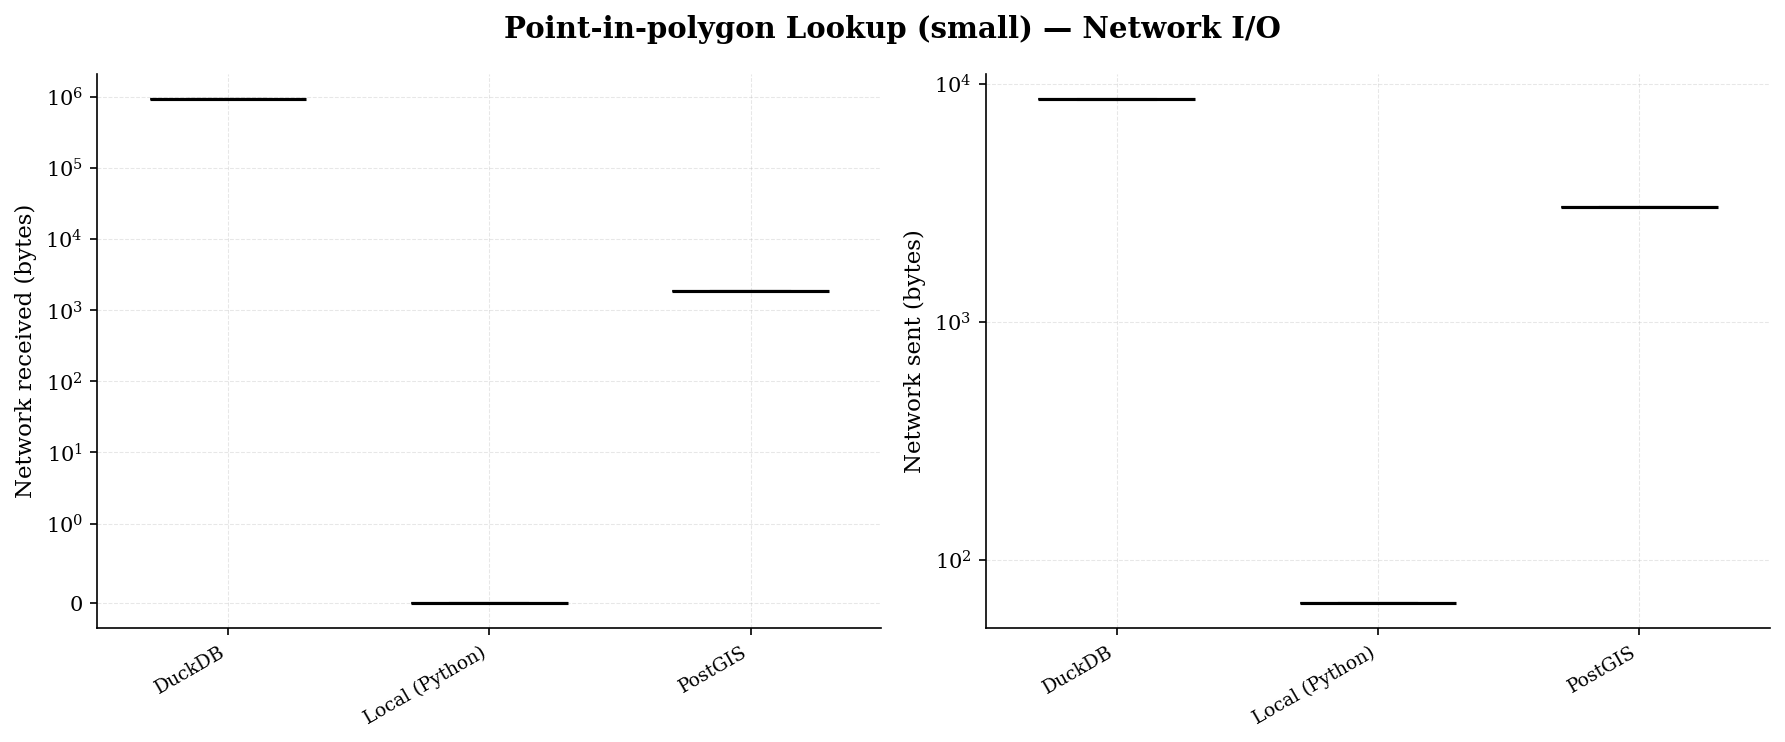

In [15]:
plot_network_io(successful, style, FIGURES_DIR)

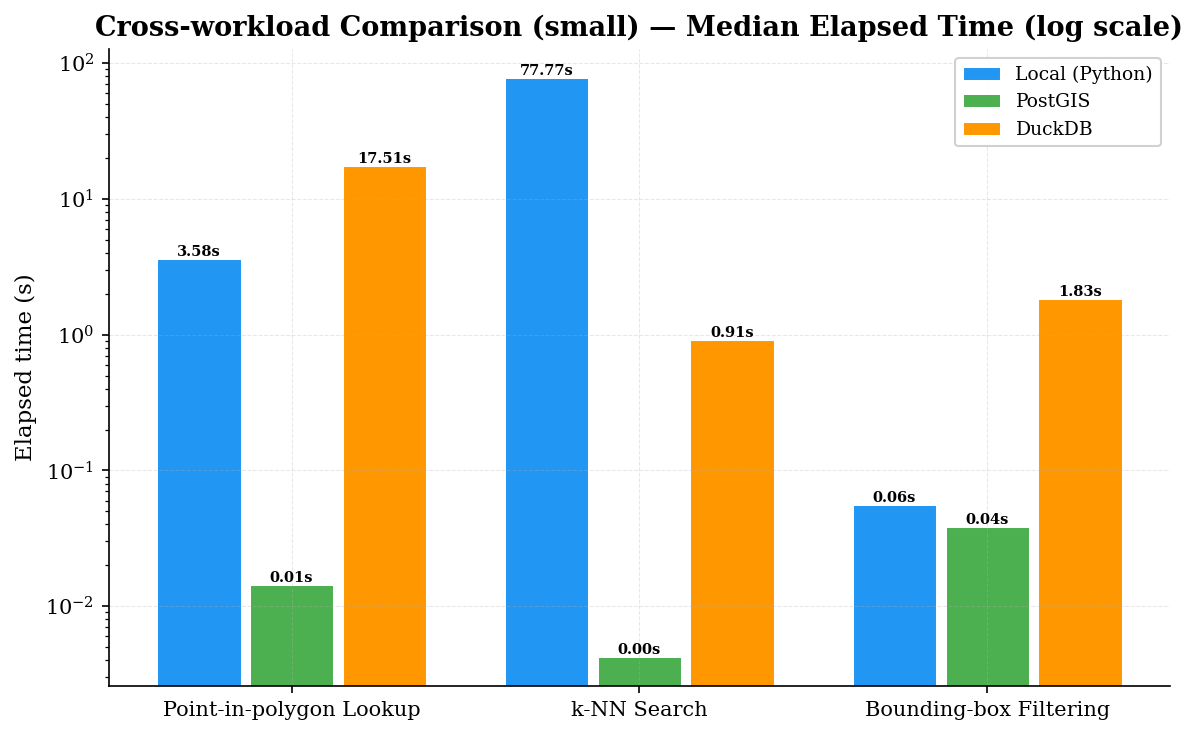

In [16]:
plot_cross_workload(successful, RQ1_WORKLOADS, RQ1_CONFIGS, style, FIGURES_DIR)

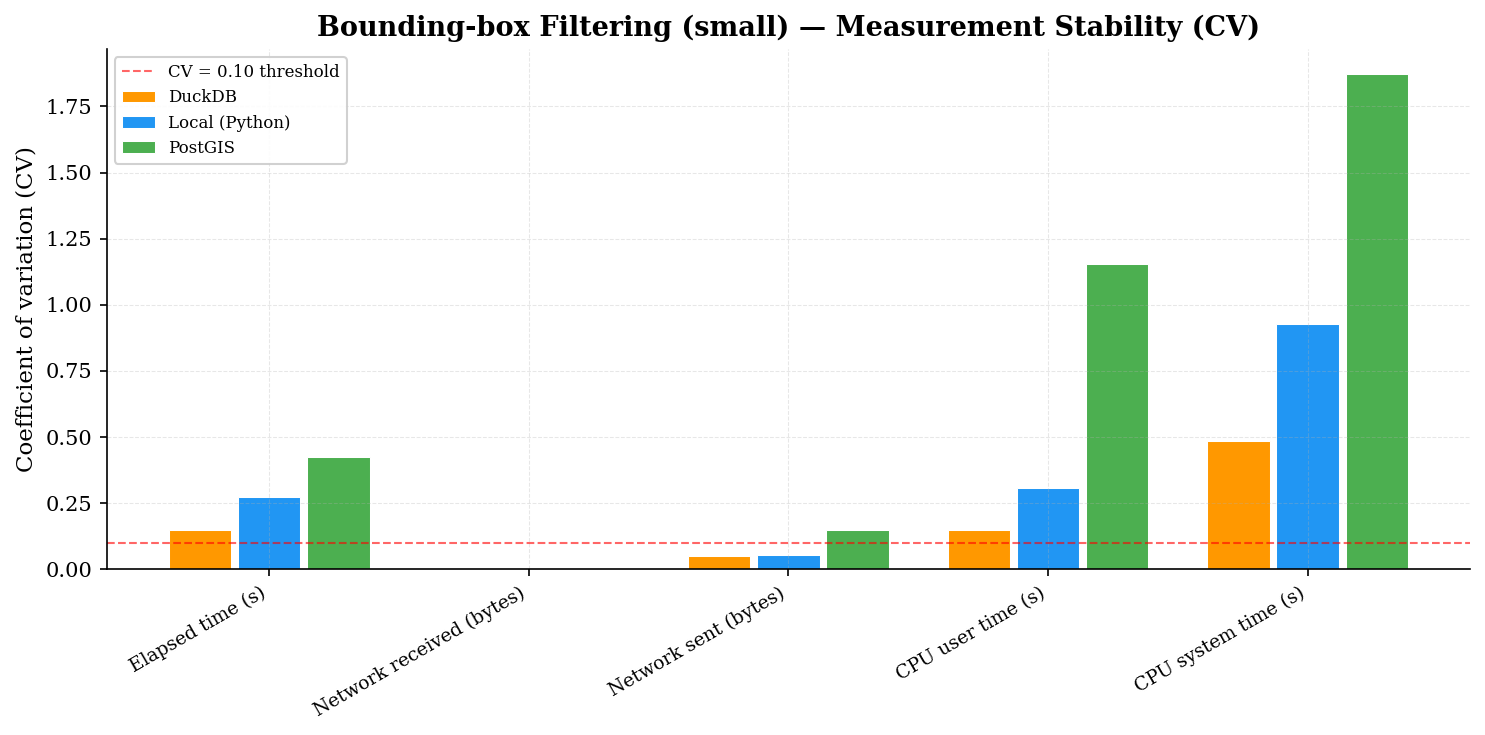

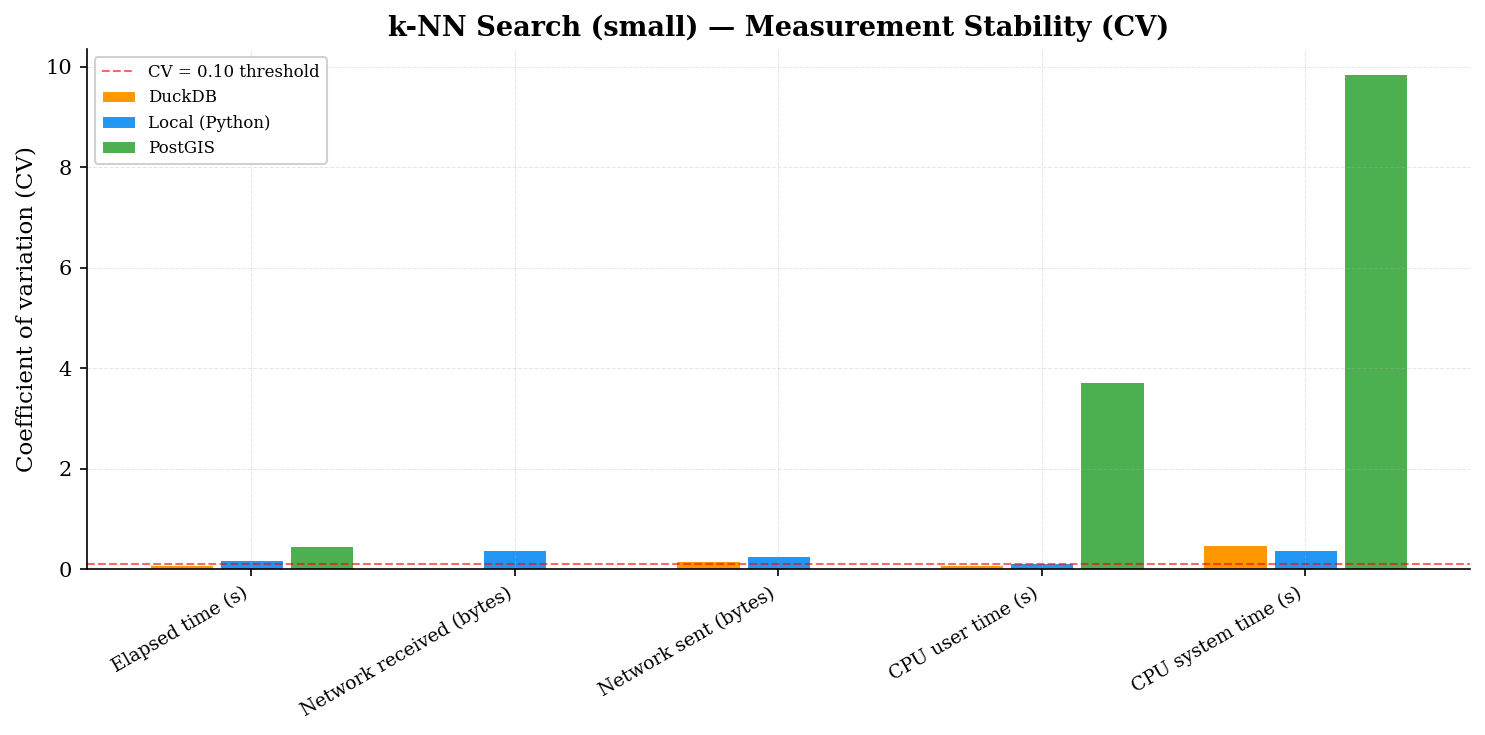

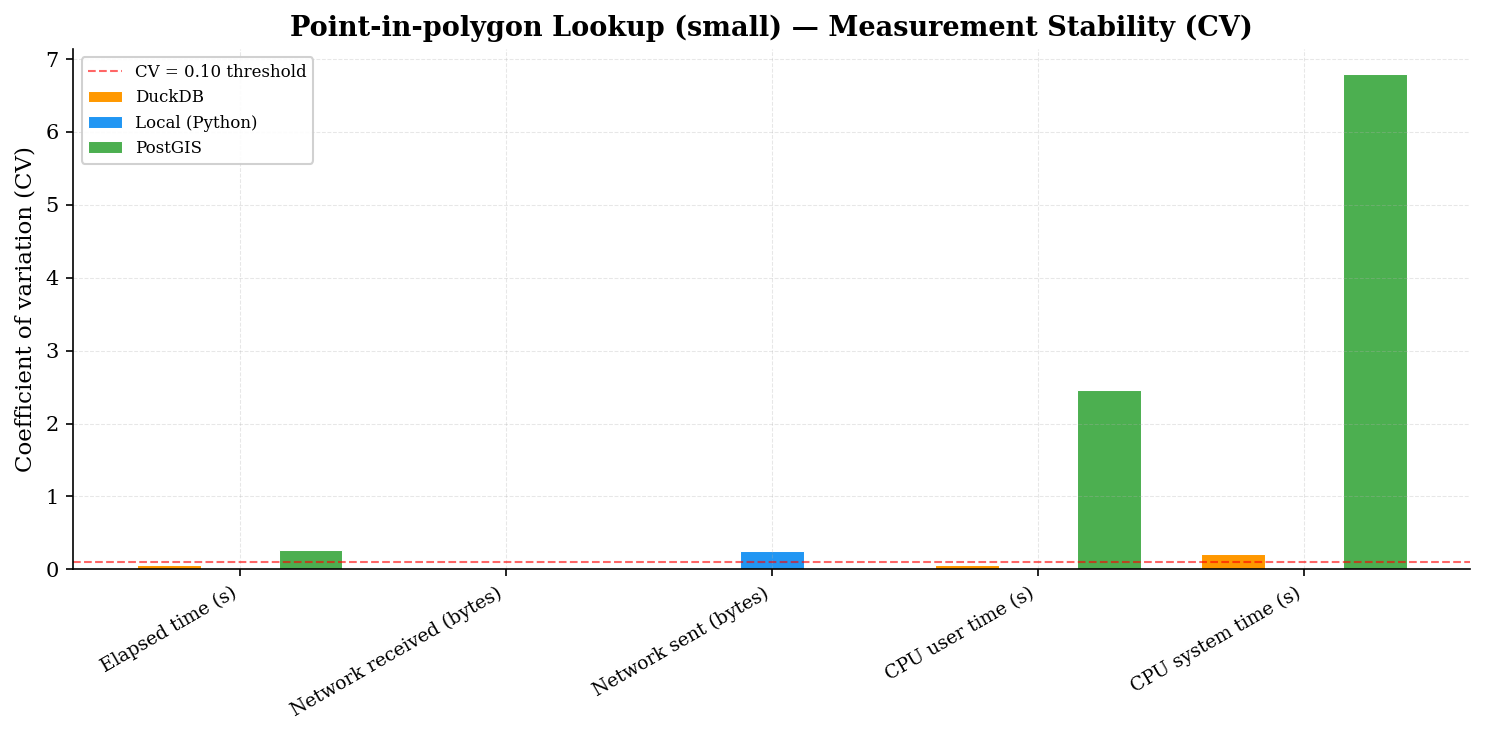

In [17]:
plot_cv_iqr(successful, PRIMARY_METRICS, AUXILIARY_METRICS, style, FIGURES_DIR)

## Cross-dataset-size Comparison

In [18]:
plot_size_scaling(successful, style, FIGURES_DIR)

table5 = build_scaling_table(successful, style.size_order)
if len(table5) > 0:
    print("Scaling factors:")
    display(table5)

In [19]:
plot_ranking_stability(successful, table3, style)

## LaTeX Export

In [20]:
# Compact descriptive stats for main text
compact_t1 = compact_descriptive_table(table1)
compact_t1.to_latex(TABLES_DIR / "table1_descriptive_stats.tex", escape=False)

# Full descriptive stats for appendix
table1.to_latex(TABLES_DIR / "table1_descriptive_stats_full.tex", escape=True, float_format="%.4f")

table2.to_latex(TABLES_DIR / "table2_cross_pass.tex", escape=True, float_format="%.4f")

if len(table3) > 0:
    split_pairwise_effects(table3).to_latex(
        TABLES_DIR / "table3a_effect_sizes.tex", escape=False, float_format="%.4f"
    )
    split_pairwise_significance(table3).to_latex(
        TABLES_DIR / "table3b_significance.tex", escape=False, float_format="%.4f"
    )

if len(table4) > 0:
    format_consistency_table(table4).to_latex(
        TABLES_DIR / "table4_consistency.tex", escape=True, index=False
    )

if len(rq1_ranking) > 0:
    format_ranking_table(rq1_ranking).to_latex(
        TABLES_DIR / "rq1_ranking.tex", escape=True, float_format="%.4f"
    )

if len(table5) > 0:
    table5.to_latex(TABLES_DIR / "table5_size_scaling.tex", escape=True, float_format="%.4f")

print(f"LaTeX tables exported to {TABLES_DIR}/")
for f in sorted(TABLES_DIR.glob("*.tex")):
    print(f"  {f.name}")

LaTeX tables exported to tables/
  rq1_ranking.tex
  rq2_table1_descriptive_stats.tex
  rq2_table1_descriptive_stats_full.tex
  rq2_table2_cross_pass.tex
  table1_descriptive_stats.tex
  table1_descriptive_stats_full.tex
  table2_cross_pass.tex
  table3_pairwise.tex
  table3a_effect_sizes.tex
  table3b_significance.tex
  table4_consistency.tex
